In [1]:
from xaikd import models, attributors, datasets
import torch
from torch.nn import functional as F
import numpy as np

from matplotlib import pyplot as plt
import timm
from torchvision import transforms as T

from PIL import Image
import requests

In [2]:
image_collection = (
    ("volcano.jpg", 980),
    ("zebra.jpg", 340),
    ("castle.jpg", 483),
    ("castle.jpg", 919),
    ("viaduct.jpg", 888),
)

def get_image(ix):
  name, target_label = image_collection[ix]

  url = f"https://github.com/p16i/drsa-demo/blob/main/tests/data/{name}?raw=true"
  img = Image.open(requests.get(url, stream=True).raw)

  return img, target_label


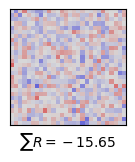

In [3]:
from matplotlib.colors import ListedColormap


# This function will be used to visualize the heatmap.
# It is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py.
def plot_heatmap(heatmap):
    """
    args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """


    b = 10 * ((np.abs(heatmap) ** 3.0).mean() ** (1.0 / 3))

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)

    txt = r"$\sum R =%.2f$" % (sum_Ri)

    # plt.imshow(heatmap, cmap="bwr", vmin=-b, vmax=b)
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)

    h = heatmap.shape[0]
    plt.xlabel(txt)
    plt.xticks([]); plt.yticks([])

plt.figure(figsize=(1.5, 1.5))
plot_heatmap(np.random.randn(28, 28))


In [4]:
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from torchvision import transforms as T

def get_input_transform(model):
  # timm provides a way to resolve (or get) transformation used by a particular model
  # via `resolve_data_config(...)`
  config = resolve_data_config({}, model=model)
  transform = create_transform(**resolve_data_config({}, model=model))

  return transform

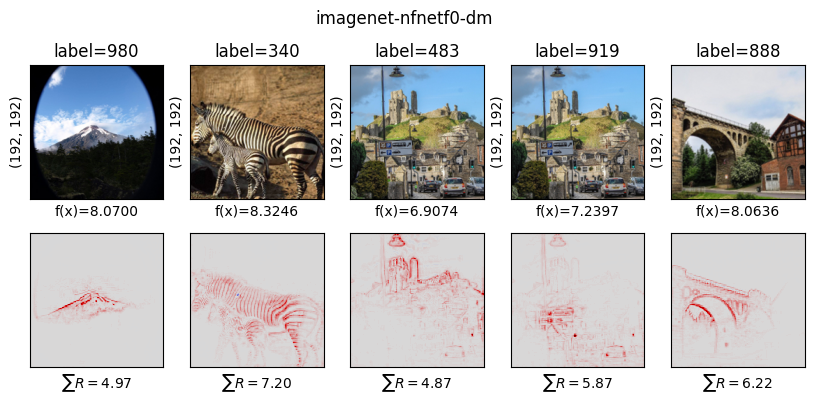

In [6]:
def viz(model_name):
    dataset = datasets.construct("imagenet")
    input_statistics = [
        dataset.input_transformation.mean,
        dataset.input_transformation.std,
    ]
    
    model = models.get_trained_model(model_name)

    if isinstance(model, timm.models.nfnet.NormFreeNet):
        input_transform = get_input_transform(model)
        rc_transform = T.Compose(input_transform.transforms[:2])
    else:
        rc_transform = T.Compose(
            [
                T.Resize(dataset.input_transformation.resize_size),
                T.CenterCrop(dataset.input_transformation.crop_size)
            ]
        )
        input_transform = dataset.input_transformation


    
    
    ncols = len(image_collection)
    nrows = 2
    plt.figure(figsize=(2*ncols, nrows*2))
    plt.suptitle(f"{model_name}",  y=1.01)
    
    with attributors.make_attributor_for(
        model=model,
        input_statistics=input_statistics
    ) as attributor:
        
        for ix in range(ncols):
            img, label = get_image(ix)
            cropped_img = rc_transform(img)
            output, heatmap = attributor(
                input_transform(img).unsqueeze(0),
                lambda output: output * F.one_hot(torch.tensor([label]), num_classes=1000)
            )

            output = output.detach().cpu().squeeze().numpy()
            heatmap = heatmap.detach().cpu().squeeze().numpy()
            
            
            plt.subplot(nrows, ncols, ix + 1)
            plt.title(f"label={label}")
            
            plt.imshow(cropped_img); plt.xticks([]); plt.yticks([])
            plt.xlabel(f"f(x)={output[label]:.4f}")
            plt.ylabel(cropped_img.size)

            plt.subplot(nrows, ncols, ncols + ix + 1)
            plot_heatmap(heatmap.sum(axis=0))
    
viz("imagenet-nfnetf0-dm")    

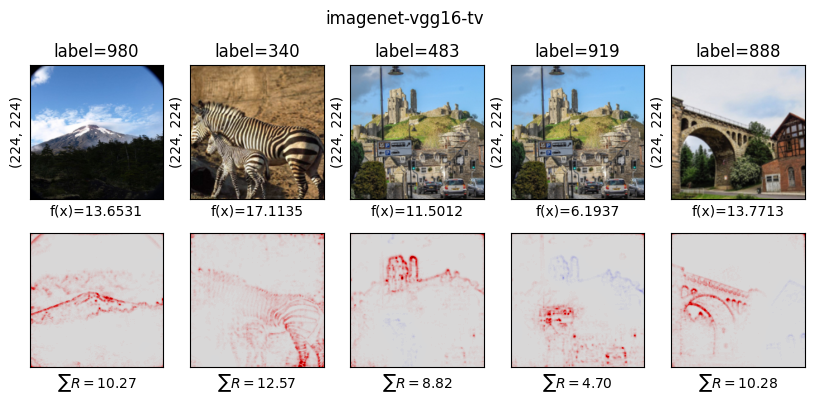

In [7]:
viz("imagenet-vgg16-tv")

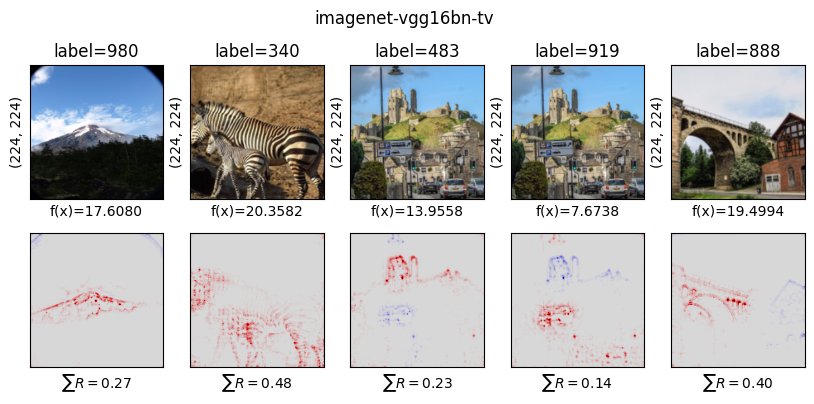

In [8]:
viz("imagenet-vgg16bn-tv")    

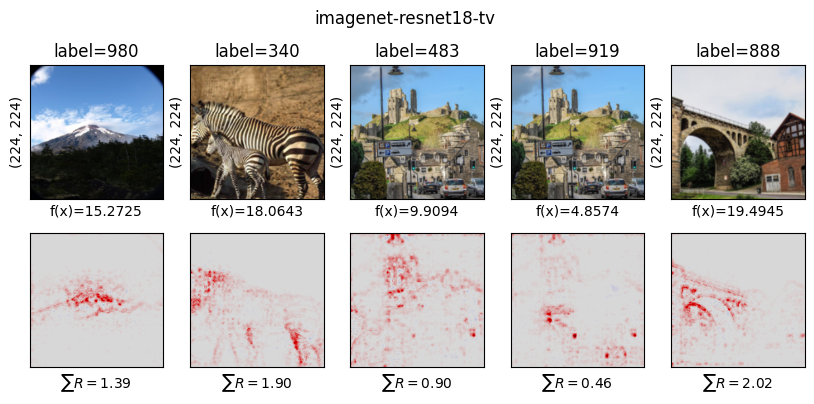

In [9]:
viz("imagenet-resnet18-tv")    